In [2]:
import sys 

sys.path.append("../../src/")
from project_imports import *

import numerical_quenches as nq 

from numerical_quenches import groundstate

import TFIM_operators_from_states as op

# The goal of this notebook is to calculate occupation numbers n_k

In [12]:
import numpy as np

def majorana_coefficients(states, L):
    """
    states : iterable of (uk, vk, k)
    L      : system size

    returns dictionary keyed by k containing
    alpha_ij, beta_ij, gamma_ij, delta_ij
    """

    sites = np.arange(L)
    i, j = np.meshgrid(sites, sites, indexing="ij")
    r = i - j

    out = {}
    us, vs, ks = states
    for uk, vk, k in zip(us,vs,ks):

        e_plus  = np.exp(1j * k * r)
        e_minus = np.exp(-1j * k * r)

        term = (abs(uk)**2 * e_plus - abs(vk)**2 * e_minus)

        alpha = term + np.conj(uk)*vk*e_plus + uk*np.conj(vk)*e_minus
        beta  = -term + np.conj(uk)*vk*e_plus - uk*np.conj(vk)*e_minus
        gamma =  term + np.conj(uk)*vk*e_plus - uk*np.conj(vk)*e_minus
        delta = -term + np.conj(uk)*vk*e_plus + uk*np.conj(vk)*e_minus

        out[k] = (alpha, beta, gamma, delta)

    return out

In [13]:
states =nq.groundstate(100,100)

In [17]:
coeffs = majorana_coefficients(states, 100)

alpha_ij, beta_ij, gamma_ij, delta_ij = coeffs[states[-1][0]]

In [ ]:
alpha_ij

np.complex128(-0.9995162807477675-0.03141075907812829j)

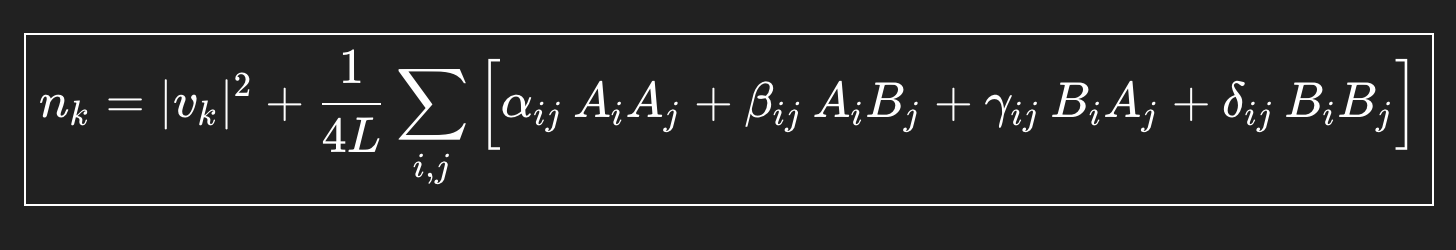

In [23]:
def sx_correlation(indices):
    """
    Computes the correlation of a string of sigma_x operators at sites labeled by indices. 
    This code commutes them into an ordered form (sigma_i<sigma_j<..)
    Then evaluates the expectation through the use of Majorana Fermions
    """
    #Remove duplicates by annihilating pairs (sigma^2=1), then sort
    counts = Counter(indices)
    indices = sorted([i for i, c in counts.items() if (c % 2) == 1])

    #If there is an odd number of sites, return 0.
    if len(indices) % 2 == 1:
        return 0

    #Trivial identity (empty string)
    if len(indices) == 0:
        return 1

    #Seperate indices into pairs
    pairs = [indices[i:i+2] for i in range(0, len(indices), 2)]

    #Create full Majorna String
    Majorana_String = op.Create_Majorana_Strings_X(pairs)

    return Majorana_String

In [33]:
def compute_string(term,state):
    majorana_cov = op.Majorana_Covariance(term,state)
    return op.Pfaffian(majorana_cov)



In [ ]:
    #Create full Covariance Matrix
    Majorana_cov = Majorana_Covariance(Majorana_String, state)

    #Evaluate expectation with Pfaffian
    return Pfaffian(Majorana_cov)


In [ ]:
def insert_nk(string,state,ki,gf):
    u,v,k = state
    L = 2*len(k)

    psi = nq.groundstate(gf,L)
    coeffs = majorana_coefficients(psi, L)
    alpha, beta, gamma, delta = coeffs[ki]
    print(alpha)
    L = 2*len(k)
    SUM_TOTAL = 0
    for i in range(L):
        for j in range(L):
            a = alpha[i,j]
            b = beta[i,j]
            c = gamma[i,j]
            d = delta[i,j]
            term1= [("A",i),("A",j)]
            term2= [("A",i),("B",j)]
            term3= [("B",i),("A",j)]
            term4= [("B",i),("B",j)]

            string_copy= string.copy()

            string1 = string_copy+ term1 + string_copy
            string2 = string_copy+ term2 + string_copy
            string3 = string_copy+ term3 + string_copy
            string4 = string_copy+ term4 + string_copy

            O1 = compute_string(string1,state)*a
            O2 = compute_string(string2,state)*b
            O3 = compute_string(string3,state)*c
            O4 = compute_string(string4,state)*d
            O = O1+O2+O3+O4

            SUM_TOTAL += O 

    return SUM_TOTAL



In [61]:
majorana_coefficients(states,10)

{np.float64(0.031415926535897934): (array([[-0.99999995+0.j        , -0.99951628-0.03141076j,
          -0.99804621-0.06279052j, -0.99559118-0.09410831j,
          -0.99215363-0.12533323j, -0.98773694-0.15643447j,
          -0.98234548-0.18738131j, -0.97598456-0.21814324j,
          -0.96866046-0.24868989j, -0.96038041-0.27899111j],
         [-0.99949674+0.03141076j, -0.99999995+0.j        ,
          -0.99951628-0.03141076j, -0.99804621-0.06279052j,
          -0.99559118-0.09410831j, -0.99215363-0.12533323j,
          -0.98773694-0.15643447j, -0.98234548-0.18738131j,
          -0.97598456-0.21814324j, -0.96866046-0.24868989j],
         [-0.99800715+0.06279052j, -0.99949674+0.03141076j,
          -0.99999995+0.j        , -0.99951628-0.03141076j,
          -0.99804621-0.06279052j, -0.99559118-0.09410831j,
          -0.99215363-0.12533323j, -0.98773694-0.15643447j,
          -0.98234548-0.18738131j, -0.97598456-0.21814324j],
         [-0.99553265+0.09410831j, -0.99800715+0.06279052j,
   

In [62]:
gf = 0
L = 10
psi = nq.groundstate(gf,L)

In [65]:
insert_nk(sx_correlation([1,2]),psi,psi[-1][0],gf)/L**2

[[-9.51056516e-01+0.j         -1.00000000e+00-0.30901699j
  -9.51056516e-01-0.58778525j -8.09016994e-01-0.80901699j
  -5.87785252e-01-0.95105652j -3.09016994e-01-1.j
  -2.22044605e-16-0.95105652j  3.09016994e-01-0.80901699j
   5.87785252e-01-0.58778525j  8.09016994e-01-0.30901699j]
 [-8.09016994e-01+0.30901699j -9.51056516e-01+0.j
  -1.00000000e+00-0.30901699j -9.51056516e-01-0.58778525j
  -8.09016994e-01-0.80901699j -5.87785252e-01-0.95105652j
  -3.09016994e-01-1.j         -2.22044605e-16-0.95105652j
   3.09016994e-01-0.80901699j  5.87785252e-01-0.58778525j]
 [-5.87785252e-01+0.58778525j -8.09016994e-01+0.30901699j
  -9.51056516e-01+0.j         -1.00000000e+00-0.30901699j
  -9.51056516e-01-0.58778525j -8.09016994e-01-0.80901699j
  -5.87785252e-01-0.95105652j -3.09016994e-01-1.j
  -2.22044605e-16-0.95105652j  3.09016994e-01-0.80901699j]
 [-3.09016994e-01+0.80901699j -5.87785252e-01+0.58778525j
  -8.09016994e-01+0.30901699j -9.51056516e-01+0.j
  -1.00000000e+00-0.30901699j -9.51056516e-

np.complex128(-0.37111300269652553+0j)

In [27]:
[2,3] + ["2"]

[2, 3, '2']

In [29]:
sx_correlation([1,2])

[('B', 1), ('A', 2)]